In [1]:
from pyscarcopula.src.N2.N2Copula import N2Copula
from pyscarcopula.src.N7.N7Copula import N7Copula
from pyscarcopula.src.N8.N8Copula import N8Copula

from pyscarcopula.src.N22.N22Copula import N22Copula
from pyscarcopula.src.N21.N21Copula import N21Copula
from pyscarcopula.src.N20.N20Copula import N20Copula

from pyscarcopula.src.Gumbel.GumbelCopula  import GumbelCopula
from pyscarcopula.src.GenestGhoudi.GenestGhoudiCopula  import GenestGhoudiCopula
from pyscarcopula.src.GumbelBarnett.GumbelBarnettCopula  import GumbelBarnettCopula
from pyscarcopula.src.Frank.FrankCopula  import FrankCopula
from pyscarcopula.src.Joe.JoeCopula  import JoeCopula
from pyscarcopula.src.AliMikhailHaq.AliMikhailHaqCopula  import AliMikhailHaqCopula

from pyscarcopula.metrics.risk_metrics import risk_metrics
from pyscarcopula.aux_functions.funcs import jit_pobs, pobs

from scipy.stats import chi2

import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import matplotlib.ticker as plticker


In [2]:
'''Read data and transform returns to pseudo observations'''
returns_data1 = pd.read_csv(r"data/test_returns_data_for_eis.csv", index_col=0) # Data from MOEX for tickers: AFKS, ROSN, SBER, YNDX. 
                                                                                # Data starts from 01.01.2020 with 30-minutes interval  
returns_data2 = pd.read_csv(r"data/dj.csv", sep=';') # Daily data of indexies DowJones и NASDAQ. 
                                                     # Data starts from 01.01.1990

moex_data = pd.read_csv("data/moex_top.csv", index_col=0)
tickers = ['AFLT', 'LSRG', 'GAZP', 'NLMK', 'ROSN', 'KMAZ', 'AFKS', 'BSPB', 'MGNT']
#tickers = ['AFLT', 'LSRG', 'GAZP', 'NLMK']
moex_returns_pd = np.log(moex_data[tickers] / moex_data[tickers].shift(1))[1:601]
moex_returns = moex_returns_pd.values
pobs_data = pobs(moex_returns)


count_instruments = len(tickers)
copula = GumbelCopula(count_instruments)

In [3]:
copula.fit(pobs_data, method='scar-p-ou')

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 522.9442977760343
       x: [ 5.173e-01  8.216e-01  3.246e-01]
     nit: 13
     jac: [-2.864e-02  2.646e-02  2.791e-02]
    nfev: 70
    njev: 13
    name: Gumbel copula
  method: SCAR-P-OU

In [67]:

print(copula.mlog_likelihood(np.array([ 1.274e+00,  2.157e+00,  1.860e-01]), pobs_data, method='scar-m-ou'))
copula.mlog_likelihood(np.array([ 1.274e+00,  2.157e+00,  1.860e-01]), pobs_data, method='scar-p-ou')

-522.5027621809822


-519.7460931038042

In [3]:
from pyscarcopula.sampler.sampler_ou import *

In [62]:
def test_m_ou(alpha, data, dwt, latent_process_tr, m_iters, print_path, pdf, transform, init_state = None):
    T = len(data)
    norm_log_data = np.zeros((T, latent_process_tr))
    dt = 1/T
    t_data = np.linspace(0, 1, T)
    a_data = np.zeros((T, 3))
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    mu = - alpha1 / alpha2
    a1t = np.zeros(T)
    a2t = np.zeros(T)
    for j in range(0, m_iters):
        if j == 0:
            lambda_data = p_sampler_ou(alpha, dwt, init_state)
        else:
            lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt, init_state)
            if np.isnan(np.sum(lambda_data)) == True:
                res = 10000
                if print_path == True:
                    print(alpha, 'm sampler nan', res)
                return res
        for i in range(1, T):
            copula_log_data = np.log(np.maximum(pdf(data[i], transform(lambda_data[i])), 1e-100))
            A = np.dstack( ( np.ones(latent_process_tr) , lambda_data[i] , lambda_data[i]**2 ) )[0]
            b = copula_log_data + norm_log_data[i - 1]
            sigma2 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * (t_data[i])))
            try:
                a_data[i] = linear_least_squares(A, b)
                a_data[i][2] = np.minimum(a_data[i][2], 1/(2 * sigma2))#1/(2 * sigma2) - 10
                a_data[i] = np.maximum(np.minimum(a_data[i], 100),-100)
            except:
                res = 10000
                if print_path == True:
                    print(alpha, 'ls problem fail', res, i)
                return res
            norm_log_data[i] = log_norm_ou(alpha, a_data[i][1], a_data[i][2], dt, lambda_data[i - 1])
        a_data_a1 = a_data[:,1].copy()
        a_data_a2 = a_data[:,2].copy()
        a1_params = poly_fit(t_data, a_data_a1, dim = 2, fit_intercept = False)
        a2_params = poly_fit(t_data, a_data_a2, dim = 2, fit_intercept = False)
        a1t = poly(t_data, a1_params, intercept = False)
        a2t = poly_corr(t_data, a2_params, alpha, intercept = False)
        ##corr_a1 = np.exp(- polyd(t_data, *a1_params)**2 / T**2) -- corr on da1/dt
        #n = T//10
        #a1t = moving_average(a_data_a1, n = n) #50
        #a2t = correction(t_data, moving_average(a_data_a2, n = n), alpha)

    log_likelihood = np.zeros(latent_process_tr)
    lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt, init_state)
    for i in range(1, T):
        a1, a2 = a1t[i], a2t[i]
        norm_log_data[i] = log_norm_ou(alpha, a1, a2, dt, lambda_data[i - 1])
    for k in prange(0, latent_process_tr):
        copula_log_data = np.log(np.maximum(pdf(data.T, transform(lambda_data[:,k])), 1e-100))
        g = (a1t * lambda_data[:,k] + a2t * lambda_data[:,k]**2)
        log_likelihood[k] = np.sum(copula_log_data + norm_log_data[:,k] - g)
    xc = np.max(log_likelihood)
    avg_likelihood = np.sum(np.exp(log_likelihood - xc)) / latent_process_tr
    res = np.log(avg_likelihood) + xc
    res = -res
    if print_path == True:
        print(alpha, res)
    return res



In [85]:
lp = 5000
#alpha = np.array([ 1.274e+00,  2.157e+00,  1.860e-01])
alpha = np.array([ 0.55014438, -0.37809041,  0.51161685]) 
alpha = np.array([0.32109396, 0.60461479, 0.22323942])

T = len(pobs_data)
m_data = []
for k in range(0, 50):
    t = np.random.randint(0, 10000000)
    rng = np.random.RandomState(t)
    dwt = rng.normal(0, 1, size = (T, lp)) * np.sqrt(1/T)
    m = test_m_ou(alpha, pobs_data, dwt, lp, 5, True, copula.np_pdf(), copula.transform)
    m_data.append(m)

[0.32109396 0.60461479 0.22323942] -525.7864836953985
[0.32109396 0.60461479 0.22323942] -527.9060296237902
[0.32109396 0.60461479 0.22323942] -525.4061525892341
[0.32109396 0.60461479 0.22323942] -525.0628710601067
[0.32109396 0.60461479 0.22323942] -529.1589214949839
[0.32109396 0.60461479 0.22323942] -526.661941393378
[0.32109396 0.60461479 0.22323942] -529.0296361087303
[0.32109396 0.60461479 0.22323942] -526.2612498781176
[0.32109396 0.60461479 0.22323942] -526.4472340352279
[0.32109396 0.60461479 0.22323942] -525.5678469029398
[0.32109396 0.60461479 0.22323942] -525.250672890552
[0.32109396 0.60461479 0.22323942] -525.2680528400911
[0.32109396 0.60461479 0.22323942] -527.0764228958601
[0.32109396 0.60461479 0.22323942] -527.479652692415
[0.32109396 0.60461479 0.22323942] -526.0977700098184
[0.32109396 0.60461479 0.22323942] -524.0390634826484
[0.32109396 0.60461479 0.22323942] -524.9515695068067
[0.32109396 0.60461479 0.22323942] -526.3275195885931
[0.32109396 0.60461479 0.223239

In [84]:
lp = 5000
alpha = np.array([ 1.274e+00,  2.157e+00,  1.860e-01])
alpha = np.array([ 0.55014438, -0.37809041,  0.51161685]) 
alpha = np.array([0.32109396, 0.60461479, 0.22323942])

T = len(pobs_data)
p_data = []
for k in range(0, 50):
    dwt = np.random.normal(0, 1, size = (T, lp)) * np.sqrt(1/T)
    p = p_jit_mlog_likelihood_ou(alpha, pobs_data, dwt, lp, True, copula.np_pdf(), copula.transform)
    p_data.append(p)

[0.32109396 0.60461479 0.22323942] -526.5267747095486
[0.32109396 0.60461479 0.22323942] -524.5400261318805
[0.32109396 0.60461479 0.22323942] -523.0029293387067
[0.32109396 0.60461479 0.22323942] -524.2262084265841
[0.32109396 0.60461479 0.22323942] -523.8147313492491
[0.32109396 0.60461479 0.22323942] -527.5459386552291
[0.32109396 0.60461479 0.22323942] -521.7997680063623
[0.32109396 0.60461479 0.22323942] -525.0087174047612
[0.32109396 0.60461479 0.22323942] -525.140817190747
[0.32109396 0.60461479 0.22323942] -524.9226912015783
[0.32109396 0.60461479 0.22323942] -523.3651537466748
[0.32109396 0.60461479 0.22323942] -524.301179644023
[0.32109396 0.60461479 0.22323942] -523.3369393633895
[0.32109396 0.60461479 0.22323942] -523.7695807737438
[0.32109396 0.60461479 0.22323942] -523.5591163076028
[0.32109396 0.60461479 0.22323942] -523.692420742843
[0.32109396 0.60461479 0.22323942] -523.4375957494954
[0.32109396 0.60461479 0.22323942] -524.2268300889041
[0.32109396 0.60461479 0.223239

In [87]:
np.mean(m_data), np.std(m_data), np.mean(p_data), np.std(p_data)

(-526.7142119533592,
 1.3977550475141918,
 -524.9375387685624,
 1.6042549998626632)

In [79]:
alpha = np.array([ 1.274e+00,  2.157e+00,  1.860e-01])
alpha = np.array([0.32109396, 0.60461479, 0.22323942])
#alpha = np.array([ 1.274e+00,  2.157e+00,  7.860e-01])
T = len(pobs_data)
t_data = np.linspace(0, 1, T)
lp = 500
mi = 5
dwt = np.random.normal(0, 1, size = (T, lp)) * np.sqrt(1/T)
a_data = test_m_ou(alpha, pobs_data, dwt, lp, mi, True, copula.np_pdf(), copula.transform)
p_jit_mlog_likelihood_ou(alpha, pobs_data, dwt, lp, True, copula.np_pdf(), copula.transform)

[0.32109396 0.60461479 0.22323942] -522.3716169680389
[0.32109396 0.60461479 0.22323942] -522.739225442101


-522.739225442101

In [45]:
@jit(nopython=True, cache = True)
def mod_abs(x):
    b = 1
    res = x * np.tanh(b * x)
    return res


# @jit(nopython=True, cache = True)
# def poly_corr(t_data, coef, alpha, intercept = True):
#     '''correct polynom fit result to be below a threshold that raises from norm constant'''
#     res = poly(t_data, coef, intercept)
#     alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
#     sigma2 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * t_data)) + 0.0001
#     #max_res = 1 / (2 * sigma2) - 1
#     max_res = 0
#     # exp_res = np.exp(-0.05*(max_res - res))
#     # return 1 / (1 + exp_res) * res
#     res = -(mod_abs(max_res - res) - max_res - res) / 2
#     return res

@jit(nopython=True, cache = True)
def poly_corr(t_data, coef, alpha, intercept = True):
    '''correct polynom fit result to be below a threshold that raises from norm constant'''
    res = poly(t_data, coef, intercept)
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    sigma2 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * t_data)) + 0.0001
    max_res = 1 / (2 * sigma2) - 1
    #max_res = 0
    exp_res = np.exp(-0.05*(max_res - res))
    return 1 / (1 + exp_res) * res

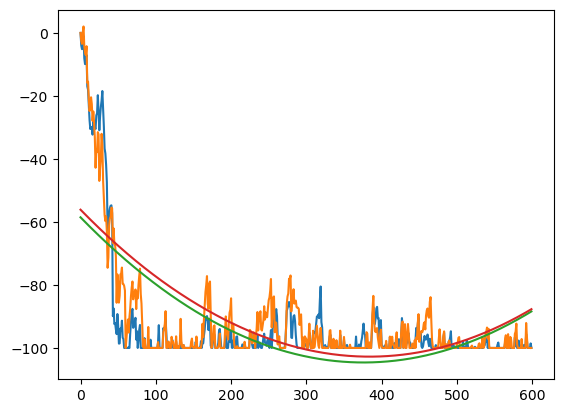

In [58]:
dim = 2
plt.plot(a_data[:,1])

plt.plot(a_data[:,2])


plt.plot(poly(t_data, poly_fit(t_data, a_data[:,1], dim = dim)))
plt.plot(poly_corr(t_data, poly_fit(t_data, a_data[:,2], dim = dim), alpha))